In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

In [6]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [7]:
!rm -rf /content/Teeth_Dataset
!cp -r "/content/drive/MyDrive/Teeth_Dataset" "/content/Teeth_Dataset"

In [8]:
train_path = "/content/Teeth_Dataset/Training"
val_path = "/content/Teeth_Dataset/Validation"
test_path = "/content/Teeth_Dataset/Testing"

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [10]:
print(os.listdir("/content/Teeth_Dataset"))

['Testing', 'Training', 'Validation']


In [11]:
train_data = ImageFolder(root=train_path, transform=train_transform)
val_data = ImageFolder(root=val_path, transform=test_transform)
test_data = ImageFolder(root=test_path, transform=test_transform)

In [12]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [13]:
model = models.resnet50(weights='IMAGENET1K_V2')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
for param in model.parameters():
    param.requires_grad = False

In [16]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_data.classes))

In [17]:
model = model.to(device)

In [18]:
class_counts = Counter(train_data.targets)
total_samples = sum(class_counts.values())
class_weights = [total_samples / class_counts[i] for i in range(len(train_data.classes))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [19]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [20]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [21]:
epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience = 5
patience_counter = 0

In [22]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/Teeth_Dataset/best_resnet50.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/50 | Train Loss: 1.5602 | Train Acc: 48.36% | Val Loss: 1.3145 | Val Acc: 63.42%
Epoch 2/50 | Train Loss: 1.1634 | Train Acc: 66.80% | Val Loss: 1.0555 | Val Acc: 72.47%
Epoch 3/50 | Train Loss: 0.9819 | Train Acc: 71.78% | Val Loss: 0.9116 | Val Acc: 76.36%
Epoch 4/50 | Train Loss: 0.8741 | Train Acc: 72.98% | Val Loss: 0.8264 | Val Acc: 78.11%
Epoch 5/50 | Train Loss: 0.7814 | Train Acc: 77.78% | Val Loss: 0.7534 | Val Acc: 79.57%
Epoch 6/50 | Train Loss: 0.7354 | Train Acc: 78.13% | Val Loss: 0.7036 | Val Acc: 82.30%
Epoch 7/50 | Train Loss: 0.6833 | Train Acc: 80.47% | Val Loss: 0.6567 | Val Acc: 82.88%
Epoch 8/50 | Train Loss: 0.6395 | Train Acc: 81.44% | Val Loss: 0.6377 | Val Acc: 81.61%
Epoch 9/50 | Train Loss: 0.5984 | Train Acc: 83.67% | Val Loss: 0.6025 | Val Acc: 85.41%
Epoch 10/50 | Train Loss: 0.5753 | Train Acc: 83.35% | Val Loss: 0.5506 | Val Acc: 86.38%
Epoch 11/50 | Train Loss: 0.5435 | Train Acc: 85.13% | Val Loss: 0.5511 | Val Acc: 85.89%
Epoch 12/50 | Train

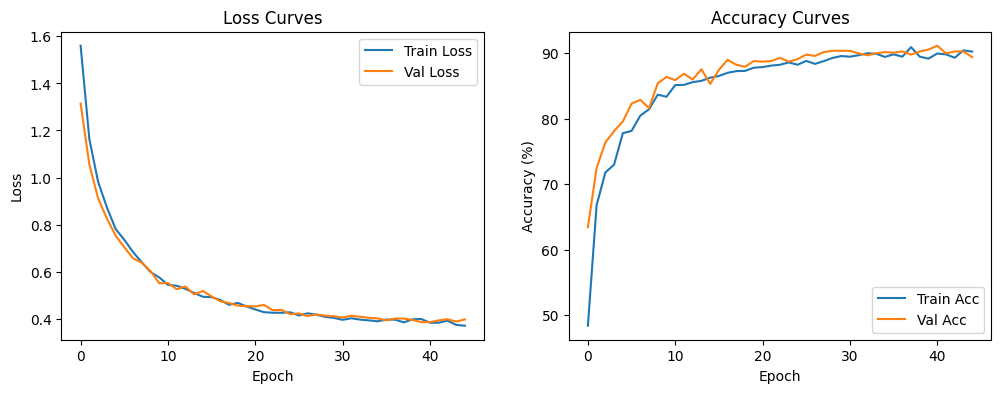

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [24]:
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

In [26]:
print(classification_report(test_targets, test_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

         CaS       0.95      0.94      0.95       160
         CoS       0.97      0.99      0.98       149
         Gum       0.86      0.95      0.90       120
          MC       0.86      0.81      0.83       180
          OC       0.82      0.89      0.85       108
         OLP       0.91      0.83      0.87       180
          OT       0.88      0.91      0.89       131

    accuracy                           0.90      1028
   macro avg       0.89      0.90      0.90      1028
weighted avg       0.90      0.90      0.90      1028



In [27]:
from google.colab import files
files.download("/content/drive/MyDrive/Teeth_Dataset/best_resnet50.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Week 3 CNN vs. Week 4 ResNet50:- Comparison Summary

The Week 3 model was a 5-layer CNN trained entirely from scratch on 128×128 images. The Week 4 model uses a ResNet50 pretrained on ImageNet, with its backbone frozen and only the final layer retrained on 224×224 images to output our 7 classes. Both models used the same class-weighted loss, learning rate scheduler, and early stopping, and were evaluated on the identical test set for a fair comparison.

ResNet50 outperformed the CNN, reaching 90% test accuracy versus the CNN's 87% (macro F1: 0.90 vs 0.87). The gain came mainly from large improvements on two classes — CaS (F1 +0.09) and CoS (F1 +0.07) — where ResNet50's pretrained features generalized especially well. The improvement wasn't universal, though: Gum and OC stayed flat, and MC actually dropped slightly (F1 0.87→0.83), suggesting the CNN's dental-specific features suited that particular class better than ResNet50's general-purpose ones.

Conclusion: transfer learning provided a clear overall improvement with minimal tuning effort, confirming that leveraging pretrained visual features is more effective than training from scratch on a dataset this size — though the CNN remains competitive on certain classes, indicating the two models learn genuinely different, not strictly better/worse, representations.